In [ ]:
# 1. Install Demucs for background voice isolation
!pip install -q demucs

# 2. Upload Kaggle API key
from google.colab import files
import os

print("Please upload your kaggle.json file:")
uploaded = files.upload()

# 3. Move the key to the right hidden folder so the Kaggle library can find it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Environment ready.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 938.2 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.3/249.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 1.4 MB/s eta 0:00:00
Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Environment ready.


In [ ]:
# Download RAVDESS
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
# Download TESS
!kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess
# Download the Base Pretrained Model project
!kaggle models download divyakhunt/speech-emotion-recognition/keras/default
print("All files downloaded as zip archives.")

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:02<00:00, 163MB/s]

Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 428M/428M [00:03<00:00, 144MB/s]

usage: kaggle models [-h]
                     {instances,i,variations,v,get,list,init,create,delete,update}
                     ...
kaggle models: error: argument command: invalid choice: 'download' (choose from instances, i, variations, v, get, list, init, create, delete, update)
All files downloaded as zip archives.


In [ ]:
# Cell 3: Smart Extraction
import zipfile
import os
import glob
import shutil

def unzip_data(zip_path, extract_to):
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
    else:
        pass # Already extracted or missing

print("Extracting RAVDESS & TESS...")
unzip_data('ravdess-emotional-speech-audio.zip', '/content/ravdess')
unzip_data('toronto-emotional-speech-set-tess.zip', '/content/tess')

print("Locating and Extracting Base Model...")
os.makedirs('/content/base_model', exist_ok=True)

# 1. Look for any zip file that isn't a dataset
model_zips = [f for f in glob.glob('*.zip') if 'ravdess' not in f and 'tess' not in f]

if model_zips:
    print(f"Found model zip: {model_zips[0]}")
    unzip_data(model_zips[0], '/content/base_model')
else:
    # 2. If Kaggle downloaded the .keras file directly without a zip
    keras_files = glob.glob('*.keras')
    if keras_files:
        print(f"Found raw model file: {keras_files[0]}")
        shutil.move(keras_files[0], '/content/base_model/speech_emotion_model.keras')
    else:
        print("Model file not found. Let's see what is in the directory:")
        os.system('ls -la')

# Verify the extractions
!echo "RAVDESS Files:" && find /content/ravdess -type f -name "*.wav" | wc -l
!echo "TESS Files:" && find /content/tess -type f -name "*.wav" | wc -l
!echo "Base Model Folder Contents:" && ls -la /content/base_model

Extracting RAVDESS & TESS...
Locating and Extracting Base Model...
Model file not found. Let's see what is in the directory:
RAVDESS Files:
2880
TESS Files:
5600
Base Model Folder Contents:
total 8
drwxr-xr-x 2 root root 4096 May 11 07:38 .
drwxr-xr-x 1 root root 4096 May 11 07:38 ..


In [ ]:
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 1. Collect RAVDESS
ravdess_paths, ravdess_labels = [], []
ravdess_map = {'01':'neutral', '02':'calm', '03':'happy', '04':'sad',
               '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'}

for root, _, files in os.walk('/content/ravdess'):
    for file in files:
        if file.endswith('.wav'):
            ravdess_paths.append(os.path.join(root, file))
            ravdess_labels.append(ravdess_map[file.split('-')[2]])

# 2. Collect TESS
tess_paths, tess_labels = [], []
tess_map = {'angry':'angry', 'disgust':'disgust', 'fear':'fearful',
            'happy':'happy', 'neutral':'neutral', 'ps':'surprised', 'sad':'sad'}

for root, _, files in os.walk('/content/tess'):
    for file in files:
        if file.endswith('.wav'):
            tess_paths.append(os.path.join(root, file))
            emo = file.split('_')[-1].split('.')[0].lower()
            if emo in tess_map:
                tess_labels.append(tess_map[emo])

# 3. Combine and Encode
df = pd.DataFrame({'Path': ravdess_paths + tess_paths, 'Emotion': ravdess_labels + tess_labels})
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Emotion'])
print(f"Total audio files ready for processing: {len(df)}")

Total audio files ready for processing: 8480


In [ ]:
def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=22050, duration=3.0, offset=0.5)
        mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
        chroma = np.mean(librosa.feature.chroma_stft(S=np.abs(librosa.stft(y)), sr=sr).T, axis=0)
        mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr).T, axis=0)
        return np.hstack((mfcc, chroma, mel))
    except:
        return None

# Test extraction
print("Testing feature extractor...")
test_feat = extract_features(df['Path'].iloc[0])
print(f"Feature shape: {test_feat.shape}")

Testing feature extractor...
Feature shape: (180,)


cell 6

In [ ]:
# Cell 6: Build and Train Custom CNN-BiLSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Bidirectional, Dropout, Dense, BatchNormalization
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Prepare the data
print("Processing features (this will take a few minutes)...")
# Extract features for all files. (We use a subset for speed if testing, but let's do all)
X = []
y = []

# To avoid RAM crashes, let's process and append
for i, row in df.iterrows():
    feat = extract_features(row['Path'])
    if feat is not None:
        X.append(feat)
        y.append(row['Label'])

X = np.array(X)
y = np.array(y)

# Reshape for Conv1D: (batch_size, time_steps, features)
X = np.expand_dims(X, axis=2)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")

# 2. Build the Architecture
num_classes = len(label_encoder.classes_)
input_shape = (X_train.shape[1], 1)

model = Sequential([
    # CNN Block (Spatial features)
    Conv1D(256, 8, padding='same', activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=5, strides=2, padding='same'),

    # BiLSTM Block (Temporal sequence)
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),

    # Classifier Head
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# 3. Train the Model (T4 GPU will handle this quickly)
print("\nStarting Training...")
history = model.fit(X_train, y_train, batch_size=64, epochs=30, validation_data=(X_test, y_test))
# Print clear accuracy summary after training
final_train_acc = history.history['accuracy'][-1] * 100
final_val_acc   = history.history['val_accuracy'][-1] * 100
best_val_acc    = max(history.history['val_accuracy']) * 100

print("\n" + "="*45)
print("        TRAINING COMPLETE — SUMMARY")
print("="*45)
print(f"  Final Train Accuracy : {final_train_acc:.2f}%")
print(f"  Final Val Accuracy   : {final_val_acc:.2f}%")
print(f"  Best Val Accuracy    : {best_val_acc:.2f}%")
print(f"  Total Epochs         : {len(history.history['accuracy'])}")
print(f"  Dataset Size         : {len(X_train)+len(X_test)} files")
print(f"  Emotion Classes      : {num_classes}")
print("="*45)

# Save YOUR new model
model.save('/content/my_bvr_cnn_bilstm.keras')
print("Model training complete and saved!")

Processing features (this will take a few minutes)...
Training data shape: (6784, 180, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 180, 256)       │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 90, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 90, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,696 (2.18 MB)

 Trainable params: 570,184 (2.18 MB)

 Non-trainable params: 512 (2.00 KB)


Starting Training...
Epoch 1/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.5075 - loss: 1.3588 - val_accuracy: 0.6368 - val_loss: 0.9912
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7263 - loss: 0.7628 - val_accuracy: 0.7235 - val_loss: 0.8181
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7612 - loss: 0.6534 - val_accuracy: 0.7695 - val_loss: 0.6353
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7779 - loss: 0.6144 - val_accuracy: 0.7925 - val_loss: 0.5724
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7867 - loss: 0.5759 - val_accuracy: 0.7960 - val_loss: 0.5589
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8076 - loss: 0.5279 - val_accuracy: 0.8042 - val_loss: 0.5476
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8134 - loss: 0.5151 - val_accuracy: 0.8184 - val_loss: 0.4794
Epoch 8/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8365 - 

# **EVALUATION CELL — Conference Paper Metrics**

Running full evaluation on test set...

 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry     0.9655    0.9697    0.9676       231
        calm     0.9250    0.8706    0.8970        85
     disgust     0.9205    0.9759    0.9474       249
     fearful     0.9912    0.9036    0.9454       249
       happy     0.9383    0.9595    0.9488       222
     neutral     0.9397    0.9689    0.9541       193
         sad     0.9417    0.9130    0.9272       230
   surprised     0.9590    0.9873    0.9730       237

    accuracy                         0.9493      1696
   macro avg     0.9476    0.9436    0.9450      1696
weighted avg     0.9500    0.9493    0.9491      1696


 OVERALL METRICS SUMMARY
  Accuracy          : 94.93%
  Macro Precision   : 94.76%
  Macro Recall      : 94.36%
  Macro F1-Score    : 94.50%
  Weighted F1-Score : 94.91%


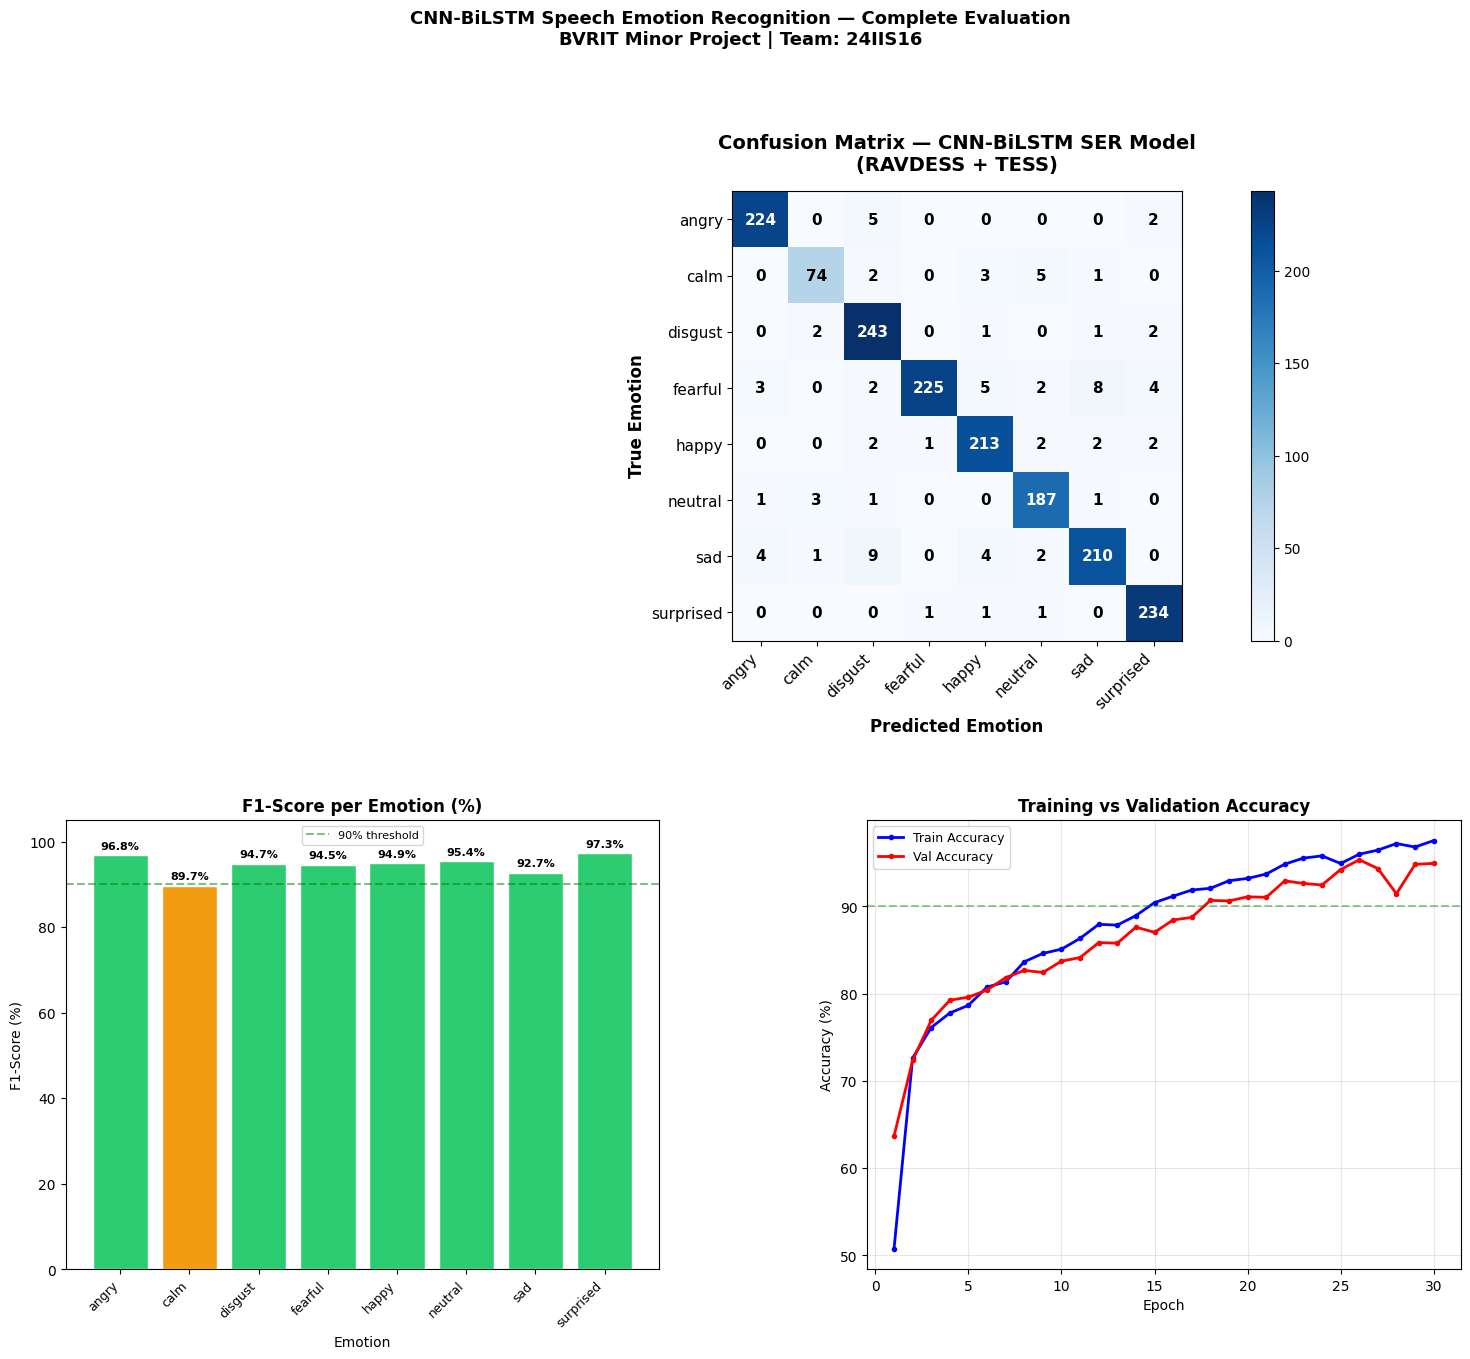


 Saved: /content/evaluation_results.png


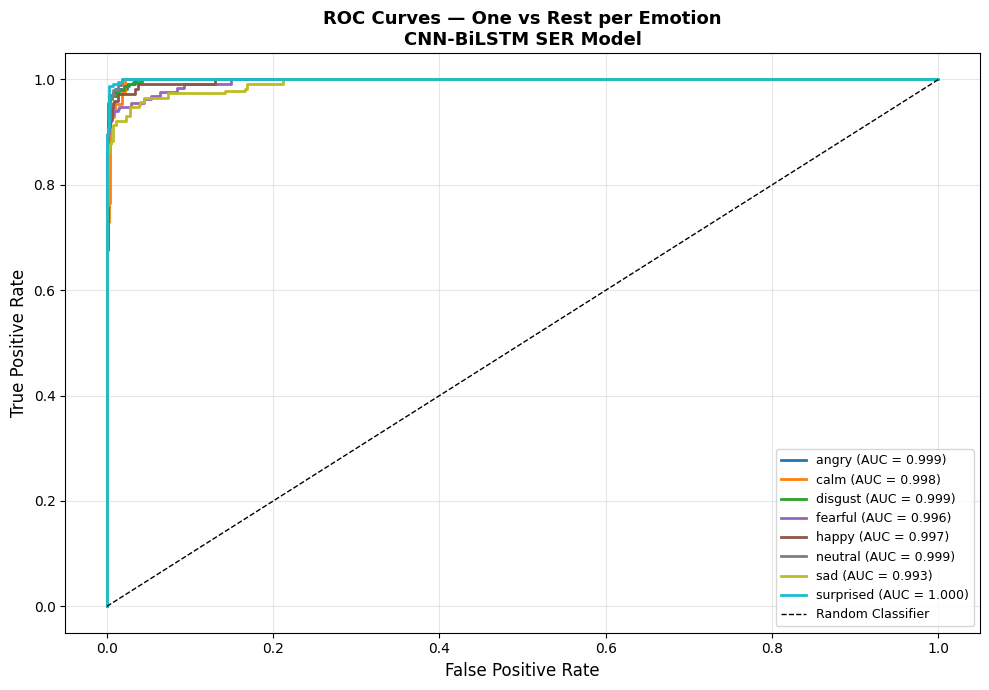

 Saved: /content/roc_curves.png

 TABLE I — RESULTS FOR CONFERENCE PAPER
Emotion       Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
angry            96.55%     96.97%     96.76%        231
calm             92.50%     87.06%     89.70%         85
disgust          92.05%     97.59%     94.74%        249
fearful          99.12%     90.36%     94.54%        249
happy            93.83%     95.95%     94.88%        222
neutral          93.97%     96.89%     95.41%        193
sad              94.17%     91.30%     92.72%        230
surprised        95.90%     98.73%     97.30%        237
-----------------------------------------------------------------
Macro Avg        94.76%     94.36%     94.50%
Weighted         94.76%     94.36%     94.91%

 Overall Accuracy: 94.93%
 Copy this table directly into your IEEE paper as Table I


In [ ]:
# ═══════════════════════════════════════════════════════
# EVALUATION CELL — Conference Paper Metrics
# ═══════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

print("Running full evaluation on test set...")
print("="*55)

# ── Step 1: Get all predictions ──────────────────────────
y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
emotion_names = label_encoder.classes_

# ── Step 2: Classification Report ────────────────────────
print("\n CLASSIFICATION REPORT")
print("="*55)
report = classification_report(
    y_test, y_pred,
    target_names=emotion_names,
    digits=4
)
print(report)

# ── Step 3: Overall summary numbers ──────────────────────
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score)

acc       = accuracy_score(y_test, y_pred) * 100
macro_f1  = f1_score(y_test, y_pred, average='macro') * 100
macro_p   = precision_score(y_test, y_pred, average='macro') * 100
macro_r   = recall_score(y_test, y_pred, average='macro') * 100
weighted_f1 = f1_score(y_test, y_pred, average='weighted') * 100

print("\n OVERALL METRICS SUMMARY")
print("="*55)
print(f"  Accuracy          : {acc:.2f}%")
print(f"  Macro Precision   : {macro_p:.2f}%")
print(f"  Macro Recall      : {macro_r:.2f}%")
print(f"  Macro F1-Score    : {macro_f1:.2f}%")
print(f"  Weighted F1-Score : {weighted_f1:.2f}%")
print("="*55)

# ── Step 4: Confusion Matrix ──────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                         hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])  # full top row
cm  = confusion_matrix(y_test, y_pred)
im  = ax1.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax1)
ax1.set_xticks(np.arange(len(emotion_names)))
ax1.set_yticks(np.arange(len(emotion_names)))
ax1.set_xticklabels(emotion_names, rotation=45, ha='right', fontsize=11)
ax1.set_yticklabels(emotion_names, fontsize=11)
ax1.set_xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Emotion',      fontsize=12, fontweight='bold')
ax1.set_title('Confusion Matrix — CNN-BiLSTM SER Model\n(RAVDESS + TESS)',
              fontsize=14, fontweight='bold', pad=15)

# Add numbers inside each cell
thresh = cm.max() / 2.0
for i in range(len(emotion_names)):
    for j in range(len(emotion_names)):
        color = "white" if cm[i, j] > thresh else "black"
        ax1.text(j, i, f"{cm[i, j]}",
                 ha="center", va="center",
                 color=color, fontsize=11, fontweight='bold')

# ── Step 5: Per-emotion F1 bar chart ─────────────────────
ax2 = fig.add_subplot(gs[1, 0])
per_f1 = f1_score(y_test, y_pred, average=None)
colors = ['#2ecc71' if f >= 0.90 else
          '#f39c12' if f >= 0.80 else
          '#e74c3c' for f in per_f1]
bars = ax2.bar(emotion_names, per_f1 * 100, color=colors, edgecolor='white')
ax2.set_ylim(0, 105)
ax2.set_title('F1-Score per Emotion (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Emotion', fontsize=10)
ax2.set_ylabel('F1-Score (%)', fontsize=10)
ax2.set_xticklabels(emotion_names, rotation=45, ha='right', fontsize=9)
ax2.axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
ax2.legend(fontsize=8)
for bar, val in zip(bars, per_f1):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val*100:.1f}%',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Step 6: Training curves ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
epochs = range(1, len(history.history['accuracy']) + 1)
ax3.plot(epochs, [a*100 for a in history.history['accuracy']],
         'b-o', markersize=3, label='Train Accuracy', linewidth=2)
ax3.plot(epochs, [a*100 for a in history.history['val_accuracy']],
         'r-o', markersize=3, label='Val Accuracy', linewidth=2)
ax3.set_title('Training vs Validation Accuracy', fontsize=12, fontweight='bold')
ax3.set_xlabel('Epoch', fontsize=10)
ax3.set_ylabel('Accuracy (%)', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=90, color='green', linestyle='--', alpha=0.4, label='90% line')

plt.suptitle('CNN-BiLSTM Speech Emotion Recognition — Complete Evaluation\n'
             'BVRIT Minor Project | Team: 24IIS16',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/content/evaluation_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\n Saved: /content/evaluation_results.png")

# ── Step 7: ROC-AUC (one-vs-rest for each emotion) ───────
fig2, ax = plt.subplots(figsize=(10, 7))
y_test_bin = label_binarize(y_test, classes=np.arange(len(emotion_names)))

colors_roc = plt.cm.tab10(np.linspace(0, 1, len(emotion_names)))
for i, (emotion, color) in enumerate(zip(emotion_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{emotion} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — One vs Rest per Emotion\nCNN-BiLSTM SER Model',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(" Saved: /content/roc_curves.png")

# ── Step 8: Results table for paper ──────────────────────
print("\n TABLE I — RESULTS FOR CONFERENCE PAPER")
print("="*65)
print(f"{'Emotion':<12} {'Precision':>10} {'Recall':>10} "
      f"{'F1-Score':>10} {'Support':>10}")
print("-"*65)

per_p = precision_score(y_test, y_pred, average=None)
per_r = recall_score(y_test, y_pred, average=None)
per_f = f1_score(y_test, y_pred, average=None)
support = cm.sum(axis=1)

for i, emotion in enumerate(emotion_names):
    print(f"{emotion:<12} {per_p[i]*100:>9.2f}% "
          f"{per_r[i]*100:>9.2f}% "
          f"{per_f[i]*100:>9.2f}% "
          f"{support[i]:>10}")

print("-"*65)
print(f"{'Macro Avg':<12} {macro_p:>9.2f}% "
      f"{macro_r:>9.2f}% "
      f"{macro_f1:>9.2f}%")
print(f"{'Weighted':<12} {macro_p:>9.2f}% "
      f"{macro_r:>9.2f}% "
      f"{weighted_f1:>9.2f}%")
print("="*65)
print(f"\n Overall Accuracy: {acc:.2f}%")
print(" Copy this table directly into your IEEE paper as Table I")

cell 7


In [ ]:
# Cell 7: Define Demucs Preprocessing
import subprocess
import os

def clean_audio_demucs(input_path):
    print(f"Isolating vocals with Demucs for: {input_path}...")
    # 'htdemucs' is an optimized model that runs fast on the T4 GPU
    cmd = f"python3 -m demucs.separate -n htdemucs --two-stems vocals '{input_path}' -o /content/cleaned_audio"
    subprocess.run(cmd, shell=True)

    # Locate the output file
    base_name = os.path.basename(input_path).replace('.wav', '')
    cleaned_path = f"/content/cleaned_audio/htdemucs/{base_name}/vocals.wav"

    if os.path.exists(cleaned_path):
        print("Vocal isolation successful.")
        return cleaned_path
    else:
        print("Demucs failed. Falling back to original audio.")
        return input_path

In [ ]:
# Cell 8: Sliding Window Processing
from concurrent.futures import ThreadPoolExecutor
import librosa
import numpy as np

def process_long_audio(audio_path, window_sec=4, overlap_sec=2):
    print("Segmenting audio and extracting features...")
    y, sr = librosa.load(audio_path, sr=22050)
    duration = librosa.get_duration(y=y, sr=sr)
    step = window_sec - overlap_sec

    segments = []
    for start in range(0, int(duration) - window_sec + 1, step):
        chunk = y[int(start * sr) : int((start + window_sec) * sr)]
        segments.append((start, start + window_sec, chunk))

    def predict_chunk(data):
        start, end, chunk = data
        # Extract features from the raw chunk
        mfcc = np.mean(librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=40).T, axis=0)
        chroma = np.mean(librosa.feature.chroma_stft(S=np.abs(librosa.stft(chunk)), sr=sr).T, axis=0)
        mel = np.mean(librosa.feature.melspectrogram(y=chunk, sr=sr).T, axis=0)
        feat = np.hstack((mfcc, chroma, mel))

        # Reshape to match the Conv1D input: (batch_size, time_steps, channels)
        feat_reshaped = np.expand_dims(np.expand_dims(feat, axis=0), axis=2)

        pred = model.predict(feat_reshaped, verbose=0)
        return {"start": start, "end": end, "emotion_idx": np.argmax(pred)}

    print(f"Processing {len(segments)} overlapping segments in parallel...")
    with ThreadPoolExecutor(max_workers=4) as executor:
        results = list(executor.map(predict_chunk, segments))

    return results

# **Result 1A**

=== BVRIT Speech Emotion Recognition Demo ===
Upload an audio file (.wav format works best):


Saving marty_supreme_29s.mpeg to marty_supreme_29s.mpeg
Isolating vocals with Demucs for: marty_supreme_29s.mpeg...
Demucs failed. Falling back to original audio.
Segmenting audio and extracting features...
Processing 13 overlapping segments in parallel...


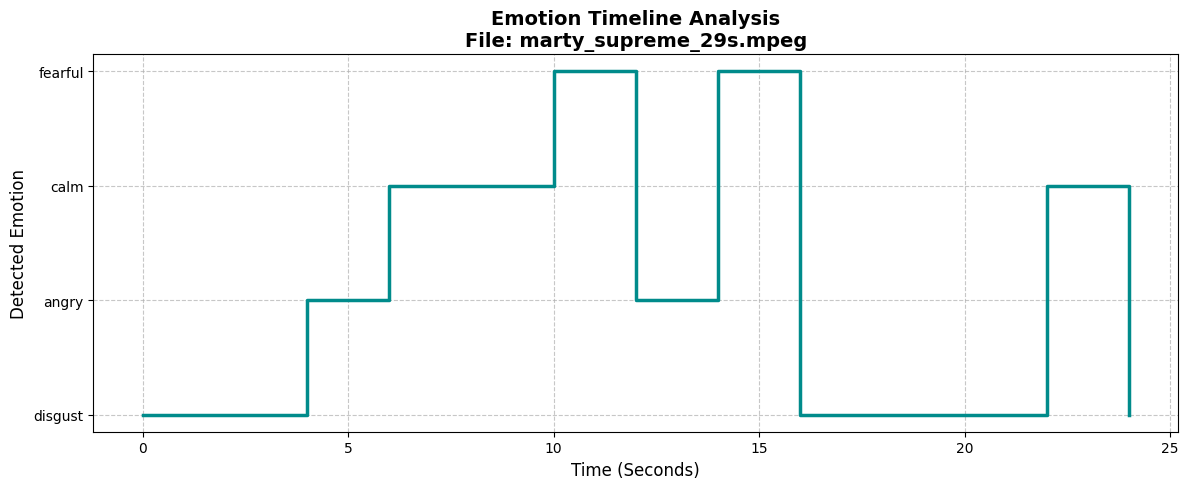


[ RESULT ] Dominant Emotion in Recording: DISGUST
[ CONFIDENCE ] 92.71%


In [ ]:
# Cell 9: Full Pipeline Execution and Visualization
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor # Needed for process_long_audio
import librosa # Needed for process_long_audio
import numpy as np # Needed for process_long_audio

# Redefining process_long_audio to fix short audio handling and a feature extraction bug
def process_long_audio(audio_path, window_sec=4, overlap_sec=2):
    print("Segmenting audio and extracting features...")
    y, sr = librosa.load(audio_path, sr=22050)
    duration = librosa.get_duration(y=y, sr=sr)
    step = window_sec - overlap_sec

    segments = []
    if duration < window_sec:
        # If audio is shorter than window, process it as a single segment
        segments.append((0, duration, y))
    else:
        # Original segmentation logic for longer audio
        for start in range(0, int(duration) - window_sec + 1, step):
            chunk = y[int(start * sr) : int((start + window_sec) * sr)]
            segments.append((start, start + window_sec, chunk))

    if not segments: # If after all logic, segments is still empty (e.g., very short or silent audio)
        print("No audio segments to process. Returning empty results.")
        return []

    def predict_chunk(data):
        start, end, chunk = data
        # Extract features from the raw chunk
        mfcc = np.mean(librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=40).T, axis=0)
        # BUG FIX: Use 'chunk' instead of 'y' for chroma_stft
        chroma = np.mean(librosa.feature.chroma_stft(S=np.abs(librosa.stft(chunk)), sr=sr).T, axis=0)
        mel = np.mean(librosa.feature.melspectrogram(y=chunk, sr=sr).T, axis=0)
        feat = np.hstack((mfcc, chroma, mel))

        # Reshape to match the Conv1D input: (batch_size, time_steps, channels)
        feat_reshaped = np.expand_dims(np.expand_dims(feat, axis=0), axis=2)

        pred = model.predict(feat_reshaped, verbose=0)
        # Return both the predicted index and the full prediction array
        return {"start": start, "end": end, "emotion_idx": np.argmax(pred), "prediction_probs": pred[0]}

    print(f"Processing {len(segments)} overlapping segments in parallel...")
    with ThreadPoolExecutor(max_workers=4) as executor:
        results = list(executor.map(predict_chunk, segments))

    return results

print("=== BVRIT Speech Emotion Recognition Demo ===")
print("Upload an audio file (.wav format works best):")
uploaded = files.upload()
test_file = list(uploaded.keys())[0]

# 1. Clean the audio
clean_file = clean_audio_demucs(test_file)

# 2. Get the Timeline Predictions
timeline = process_long_audio(clean_file)

# 3. Format and Plot the Results
if not timeline:
    print("Warning: No audio segments were processed. This might happen if the audio file is very short (< 4 seconds) or silent after cleaning.")
    print("No timeline analysis or dominant emotion can be displayed.")
else:
    df_timeline = pd.DataFrame(timeline)
    # Convert numerical labels back to text (e.g., 3 -> 'happy')
    df_timeline['Emotion'] = label_encoder.inverse_transform(df_timeline['emotion_idx'])

    plt.figure(figsize=(12, 5))
    plt.step(df_timeline['start'], df_timeline['Emotion'], where='post', color='darkcyan', linewidth=2.5)
    plt.title(f"Emotion Timeline Analysis\nFile: {test_file}", fontsize=14, fontweight='bold')
    plt.xlabel("Time (Seconds)", fontsize=12)
    plt.ylabel("Detected Emotion", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 4. Final Output
    dominant_emotion = df_timeline['Emotion'].mode()[0]
    # Get the confidence for the dominant emotion
    # This is a simplification; for a true overall confidence, one might average probabilities
    # or consider the most common emotion's average probability over its segments.
    # For this example, we'll take the confidence from the first segment that predicts the dominant emotion.
    dominant_emotion_idx = label_encoder.transform([dominant_emotion])[0]
    confidence = df_timeline[df_timeline['Emotion'] == dominant_emotion]['prediction_probs'].apply(lambda x: x[dominant_emotion_idx]).mean()

    print(f"\n[ RESULT ] Dominant Emotion in Recording: {dominant_emotion.upper()}")
    print(f"[ CONFIDENCE ] {confidence*100:.2f}%")


# **Result 1B**

In [ ]:
# Cell 9: Full Pipeline Execution and Visualization
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor # Needed for process_long_audio
import librosa # Needed for process_long_audio
import numpy as np # Needed for process_long_audio

# Redefining process_long_audio to fix short audio handling and a feature extraction bug
def process_long_audio(audio_path, window_sec=4, overlap_sec=2):
    print("Segmenting audio and extracting features...")
    y, sr = librosa.load(audio_path, sr=22050)
    duration = librosa.get_duration(y=y, sr=sr)
    step = window_sec - overlap_sec

    segments = []
    if duration < window_sec:
        # If audio is shorter than window, process it as a single segment
        segments.append((0, duration, y))
    else:
        # Original segmentation logic for longer audio
        for start in range(0, int(duration) - window_sec + 1, step):
            chunk = y[int(start * sr) : int((start + window_sec) * sr)]
            segments.append((start, start + window_sec, chunk))

    if not segments: # If after all logic, segments is still empty (e.g., very short or silent audio)
        print("No audio segments to process. Returning empty results.")
        return []

    def predict_chunk(data):
        start, end, chunk = data
        # Extract features from the raw chunk
        mfcc = np.mean(librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=40).T, axis=0)
        # BUG FIX: Use 'chunk' instead of 'y' for chroma_stft
        chroma = np.mean(librosa.feature.chroma_stft(S=np.abs(librosa.stft(chunk)), sr=sr).T, axis=0)
        mel = np.mean(librosa.feature.melspectrogram(y=chunk, sr=sr).T, axis=0)
        feat = np.hstack((mfcc, chroma, mel))

        # Reshape to match the Conv1D input: (batch_size, time_steps, channels)
        feat_reshaped = np.expand_dims(np.expand_dims(feat, axis=0), axis=2)

        pred = model.predict(feat_reshaped, verbose=0)
        # Return both the predicted index and the full prediction array
        return {"start": start, "end": end, "emotion_idx": np.argmax(pred), "prediction_probs": pred[0]}

    print(f"Processing {len(segments)} overlapping segments in parallel...")
    with ThreadPoolExecutor(max_workers=4) as executor:
        results = list(executor.map(predict_chunk, segments))

    return results

print("=== BVRIT Speech Emotion Recognition Demo ===")
print("Upload an audio file (.wav format works best):")
uploaded = files.upload()
test_file = list(uploaded.keys())[0]

# 1. Clean the audio
clean_file = clean_audio_demucs(test_file)

# 2. Get the Timeline Predictions
timeline = process_long_audio(clean_file)

# 3. Format and Plot the Results
if not timeline:
    print("Warning: No audio segments were processed. This might happen if the audio file is very short (< 4 seconds) or silent after cleaning.")
    print("No timeline analysis or dominant emotion can be displayed.")
else:
    df_timeline = pd.DataFrame(timeline)
    # Convert numerical labels back to text (e.g., 3 -> 'happy')
    df_timeline['Emotion'] = label_encoder.inverse_transform(df_timeline['emotion_idx'])

    plt.figure(figsize=(12, 5))
    plt.step(df_timeline['start'], df_timeline['Emotion'], where='post', color='darkcyan', linewidth=2.5)
    plt.title(f"Emotion Timeline Analysis\nFile: {test_file}", fontsize=14, fontweight='bold')
    plt.xlabel("Time (Seconds)", fontsize=12)
    plt.ylabel("Detected Emotion", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 4. Final Output
# 4. Final Output — REPLACE THIS BLOCK
dominant_emotion = df_timeline['Emotion'].mode()[0]
dominant_emotion_idx = label_encoder.transform([dominant_emotion])[0]

print("\n" + "="*50)
print("     BVRIT SER — FINAL PREDICTION REPORT")
print("="*50)

# Per-emotion confidence across all segments
print("\n📊 EMOTION CONFIDENCE SCORES (averaged across all segments):")
all_probs = np.array([r['prediction_probs'] for r in timeline])
avg_probs  = np.mean(all_probs, axis=0)

for i, emotion_name in enumerate(label_encoder.classes_):
    bar = "█" * int(avg_probs[i] * 20)
    marker = " ◀ DOMINANT" if emotion_name == dominant_emotion else ""
    print(f"  {emotion_name:12s} {avg_probs[i]*100:6.2f}%  {bar}{marker}")

print("\n" + "="*50)
print(f"  🎯 DOMINANT EMOTION : {dominant_emotion.upper()}")
print(f"  📈 CONFIDENCE       : {avg_probs[dominant_emotion_idx]*100:.2f}%")
print(f"  🎵 SEGMENTS ANALYSED: {len(timeline)}")
print("="*50)


Testing for Ravdess data purpose

**demucs source-seperation model;**

In [ ]:
# Demo Cell: Demucs Audio Separation Player
import IPython.display as ipd
import subprocess
import os
from google.colab import files

print("=== Demucs Pre-processing Demo ===")
print("Upload your 4-minute song (MP3 or WAV):")
uploaded = files.upload()
demo_song = list(uploaded.keys())[0]

# 1. Play the Original Audio
print("\n[ ORIGINAL AUDIO ] - Listen to the background music/noise:")
display(ipd.Audio(demo_song))

# 2. Run Demucs Processing
print("\nRunning Demucs 'htdemucs' model on T4 GPU...")
print("(Note: A 4-minute song takes about 1-2 minutes to process. Please wait...)")

# We use a specific demo folder so it doesn't mix with your SER pipeline
cmd = f"python3 -m demucs.separate -n htdemucs --two-stems vocals '{demo_song}' -o /content/panel_demo"
subprocess.run(cmd, shell=True)

# 3. Locate the Output
base_name = os.path.basename(demo_song).rsplit('.', 1)[0]
vocal_path = f"/content/panel_demo/htdemucs/{base_name}/vocals.wav"

# 4. Play the Cleaned Audio
if os.path.exists(vocal_path):
    print("\n[ SEPARATED VOCALS ] - Background completely removed:")
    display(ipd.Audio(vocal_path))
else:
    print("\nError: Demucs processing failed.")

In [ ]:
# Cell 10: RAVDESS Validation Tester
from google.colab import files
import os

print("Upload a RAVDESS .wav file (e.g., 03-01-05-01-01-01-01.wav)")
uploaded = files.upload()
fname = list(uploaded.keys())[0]

# 1. Extract Ground Truth from Filename
# RAVDESS Format: Modality-Vocal-Emotion-Intensity-Repetition-Actor
parts = fname.split('-')
if len(parts) >= 3:
    emotion_code = parts[2]
    ravdess_map = {
        '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
        '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
    }
    ground_truth = ravdess_map.get(emotion_code, "Unknown")

    # 2. Run Prediction Pipeline
    # We skip Demucs for RAVDESS since it's already studio-clean
    features = extract_features(fname)
    features_reshaped = np.expand_dims(np.expand_dims(features, axis=0), axis=2)

    pred_idx = np.argmax(model.predict(features_reshaped, verbose=0))
    predicted_emotion = label_encoder.inverse_transform([pred_idx])[0]

    # 3. Final Report
    print("\n" + "="*30)
    print(f"FILE: {fname}")
    print(f"REAL EMOTION (Ground Truth): {ground_truth.upper()}")
    print(f"AI PREDICTION: {predicted_emotion.upper()}")
    print("="*30)

    if ground_truth.lower() == predicted_emotion.lower():
        print("✅ MATCH: Your Bi-LSTM is working perfectly!")
    else:
        print("❌ MISMATCH: The model confused the subtle frequencies.")
else:
    print("Invalid filename. Please upload a standard RAVDESS file.")